In [15]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter

from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
combo_df = load_hpc_result(Path("../data/RF_results/RF_combo_results.pkl"), "topo+QM")
topo_df = load_hpc_result(Path("../data/RF_results/RF_topo_results.pkl"), "topo")
qm_df = load_hpc_result(Path("../data/RF_results/RF_qm_results.pkl"), "QM")

combo_filtered_df = load_hpc_result(Path("../data/RF_results/RF_combo_filtered_results.pkl"), "topo+QM_filtered")
topo_filtered_df = load_hpc_result(Path("../data/RF_results/RF_topo_filtered_results.pkl"), "topo_filtered")

In [13]:
r2_df = pd.concat([df[["name", "test_r2"]] for df in [topo_df, combo_df, combo_filtered_df, qm_df]])

In [38]:
print(combo_df["test_r2"].mean())
print(topo_df["test_r2"].mean())
print(combo_filtered_df["test_r2"].mean())
print(topo_filtered_df["test_r2"].mean())
print(qm_df["test_r2"].mean())

0.8623207995230464
0.8623207995230464
0.861941642782758
0.8623207995230464
0.8623207995230464


C:\Users\thibo\AppData\Local\Temp\ipykernel_16116\1426857833.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


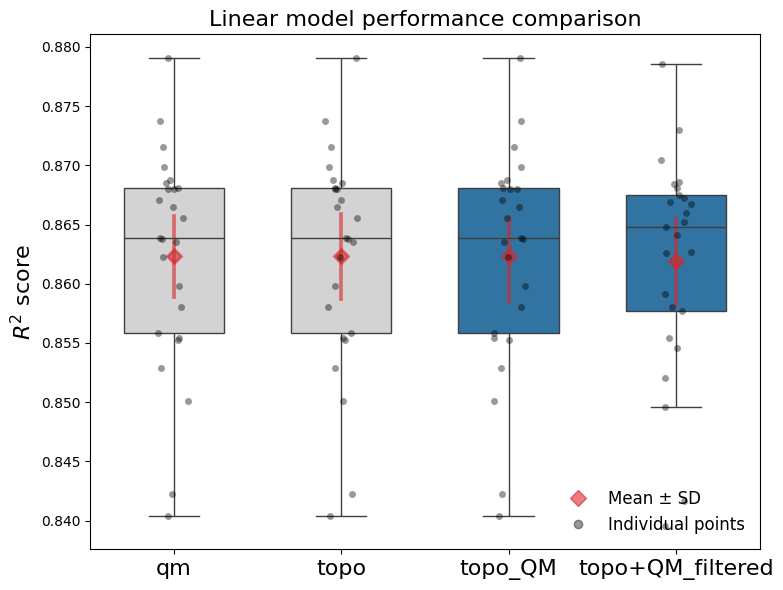

In [14]:
order = (
    r2_df.groupby("name")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# blue_models = ["topo+QM", "topo+QM_rfe", "topo+QM_filtered", "topo+QM_filtered_rfe"]

palette = {
    model: "tab:blue" if 'QM' in model else "lightgray"
    for model in r2_df["name"].unique()
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df,
    x="name",
    y="test_r2",
    order=order,
    palette=palette,
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df,
    x="name",
    y="test_r2",
    order=order,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df, x="name", y="test_r2", color="black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    # Patch(facecolor="tab:blue", edgecolor="black", label="QM + topo"),
    # Patch(facecolor="lightgray", edgecolor="black", label="Topo-only"),
    Patch(facecolor="tab:red", edgecolor="black", label="Mean ± SD"),
    Patch(facecolor="black", edgecolor="black", label="Individual points", alpha=0.4)
]

plt.legend(handles=[point_handle, strip_handle], loc="lower right", frameon=False, fontsize=12)

plt.xticks(fontsize=16)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Linear model performance comparison", fontsize=16)
# plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

In [23]:
compare(combo_df, topo_df, qm_df, n_tot=8763)

topo_QM mean r2: 0.8623207995230464 (Train: 0.9621412435332876)
topo mean r2: 0.8623207995230464 (Train: 0.9621412435332876)
qm mean r2: 0.8623207995230464 (Train: 0.9621412435332876)
Mean improvement: 0.0
T-test p-value: nan -> statistically significant
Wilcoxon p-value: nan -> statistically significant


topo_QM mean MSE: 0.7324992185252459 (Train: 0.20164229395787178)
topo mean MSE: 0.7324992185252459 (Train: 0.20164229395787178)
qm mean MSE: 0.7324992185252459 (Train: 0.20164229395787178)
Mean improvement: 0.0
T-test p-value: nan -> statistically significant
Wilcoxon p-value: nan -> statistically significant




C:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\ml_enhance\model_analysis\statistical_tests.py:69: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = mean_diff / np.sqrt(corrected_var)
c:\Users\thibo\OneDrive\Bureaublad\Enhancing-aqueous-solubility-prediction-models\.venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [42]:
best_idx = combo_df["test_r2"].argmax()
best_model = combo_df["estimator"].iloc[best_idx]

print("Best score:", best_model.best_score_)
print("Best params:", best_model.best_params_)

Best score: 0.8535919713505005
Best params: {'predict__max_depth': 33, 'predict__max_features': 0.3, 'predict__min_samples_leaf': 1, 'predict__min_samples_split': 13, 'predict__n_estimators': 776}
